In [4]:
checks[ship.position] += 0.5
paths[home] += 0.5

path = astar(ship.position, goal=home,
    neighbors_fnct=neighbors,
    distance_between_fnct=lambda *x: heur(ship, *x),
    heuristic_cost_estimate_fnct=dist
)
draw_path(paths, path[ship.position])
print(f"{len(path[ship.position])} steps")

halite = 0
for n in path[ship.position][1:]:
    halite += map[n] / EXTRACT_RATIO
    halite -= map[n] / MOVE_COST_RATIO
print(f"{halite} halite")

UnboundLocalError: local variable 'nvisits' referenced before assignment

In [39]:
np.dstack([map, checks, paths]).astype(float)

In [40]:
s, t = (19,46), (42,7)

maze = copy(default_maze)

for _ in range(300):  # add random blocks
    maze[np.random.randint(maze.shape[0]), np.random.randint(maze.shape[1])] = 0.0

len:65 visits:[1218]


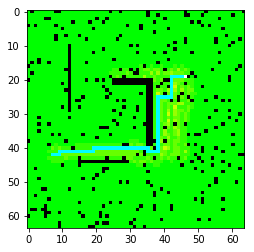

In [41]:
n_visits[0] = 0
img, visited = np.zeros_like(default_maze), np.zeros_like(default_maze)

path = astar( s, goal=t,
    neighbors_fnct=neighbors_manh, 
    distance_between_fnct=manh,
    heuristic_cost_estimate_fnct=manh
)
#path = find_path( s, goal=t,
#    neighbors_fnct=neighbors_manh, 
#    distance_between_fnct=manh,
#    heuristic_cost_estimate_fnct=manh
#)
#path = list(path)
print(f"len:{len(path[s])} visits:{n_visits}")

for p in path:
    break

draw_path(path[s])
visited[s] = 1.0

#cv2.namedWindow(str((sy,sx))+str((ty,tx)),cv2.WINDOW_NORMAL)
#cv2.imshow(str((sy,sx))+str((ty,tx)),np.dstack((maze, visited, img)))
#cv2.resizeWindow(str((sy,sx))+str((ty,tx)), 600,600)
#cv2.waitKey(0)
#cv2.destroyAllWindows()

image = np.dstack((visited, maze, img))
plt.figure()
plt.imshow(image)
plt.show()

In [42]:
maze, img, visited = copy(default_maze), np.zeros_like(maze), np.zeros_like(maze)
n_visits[0] = 0

# add random blocks
for _ in range(400):
    maze[np.random.randint(maze.shape[0]), np.random.randint(maze.shape[1])] = 0.0

# get a start point that is traversible
while True:
    s = np.random.randint(int(maze.shape[0])), np.random.randint(int(maze.shape[1]))
    if maze[s]!=0.0:
        break

# get target
while True:
    t = np.random.randint(maze.shape[0]), np.random.randint(maze.shape[1])
    if maze[t]!=0.0:
        break

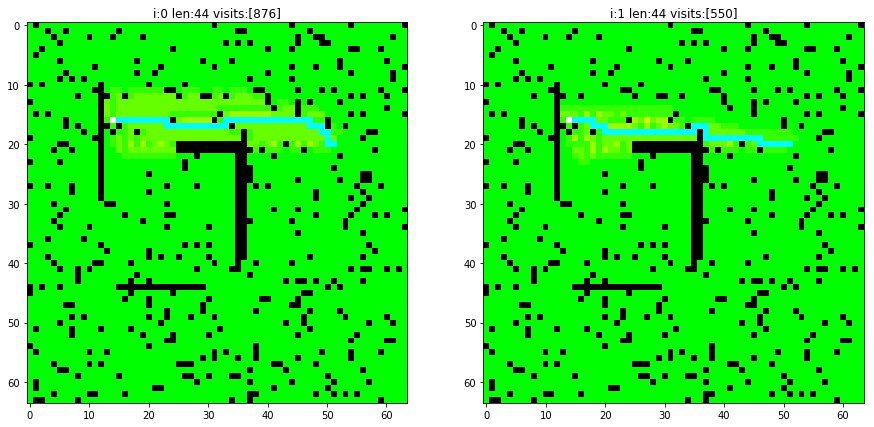

In [43]:
if not all([maze[s], maze[t]]):
    print(f'invalid start or target\n{maze[s], maze[t]}')
else:
    plt.subplots(1,2, figsize=(15,15))

    for idx, v in enumerate([(eucl, eucl), (manh, manh)]):
        d, h = v[0], v[1]
        n_visits[0] = 0
        # repeat last
        img = np.zeros_like(maze)
        visited = np.zeros_like(maze)
        # find path
        path = astar( s, goal=t,
            neighbors_fnct=neighbors_manh,
            distance_between_fnct=d,
            heuristic_cost_estimate_fnct=h
        )

        # draw, show, etc.
        plt.subplot(1,2,idx+1)
        if path[s][0] is not None:
            draw_path(path[s])
            visited[s] = 1.0
            plt.title(f"i:{idx} len:{len(path[s])} visits:{n_visits}")
            image = np.dstack((visited, maze, img))
        else:
            plt.title(f"no path {s} to {t}")
            img[s] = 1.0
            img[t] = 1.0
            image = np.dstack((blank, maze, img))
        plt.imshow(image)

    plt.show()